In [52]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import  LinearRegression 
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import cross_val_score
# 1. Set the random seed based on your Student ID's last two digits. 

#    Example: If your ID ends in 73 => np.random.seed(37). 
#    If your ID ends in 00 => np.random.seed(1). 
np.random.seed(17) 
 
# 2. Number of samples 
n_samples = 120 
 
# 3. Generate synthetic features 
Size = np.random.uniform(50, 300, n_samples)          # e.g., 50m^2 to 300m^2 
Num_Rooms = np.random.randint(1, 8, n_samples)        # integer, 1 to 7 rooms 
Location_Score = np.random.uniform(0, 10, n_samples)  # 0 to 10 rating 
 
# 4. Define a polynomial-like relationship for house price (target) 
#    Feel free to adjust coefficients, but do not change the "structure" 
House_Price = ( 
    1000 
    + 3.5 * Size 
    + 800 * (Num_Rooms ** 2) 
    - 50 * (Location_Score ** 2) 
    + 100 * (Size * Location_Score) 
    + np.random.normal(0, 2000, n_samples)  # Noise 
) 
 
# Combine into a DataFrame 
df_real_estate = pd.DataFrame({ 
    'Size': Size, 
    'Num_Rooms': Num_Rooms, 
    'Location_Score': Location_Score, 
    'House_Price': House_Price 
}) 
 
# Inspect first few rows 
print(df_real_estate.head()) 

         Size  Num_Rooms  Location_Score    House_Price
0  123.666251          1        0.453638    8734.489598
1  182.646689          1        8.811558  160183.578625
2   97.880197          3        8.934314   93554.803756
3   66.975090          2        3.337557   25904.513721
4  246.746365          6        3.385110  108917.535988


### Q1: Exploratory Data Analysis

> 1. Describe the dataset in terms of: 

>> *Number of features vs. samples.  

In [53]:
# Check dataset feature & shape
print(f"Dataset features: {df_real_estate.columns}")
print(f"Dataset shape: {df_real_estate.shape}")  

Dataset features: Index(['Size', 'Num_Rooms', 'Location_Score', 'House_Price'], dtype='object')
Dataset shape: (120, 4)


Thus, the dataset has 120 rows and 4 columns.
Number of samples (rows): 120
Number of features (columns): 3 independent variables (Size, Num_Rooms, Location_Score) + 1 dependent variable (House_Price)

>> ** Statistical summaries (std, median, mean, min, max) of each feature (including the target). 

In [54]:
# Summary statistics
print(df_real_estate.describe().loc[["std", "50%", "mean", "min", "max"]].rename(index={"50%":"median"}))

              Size  Num_Rooms  Location_Score    House_Price
std      73.446161   2.049783        2.834620   67880.800333
median  184.448166   4.000000        5.508106  105690.217374
mean    179.247300   3.908333        5.297737  111403.799891
min      53.924048   1.000000        0.019382     994.066527
max     297.001665   7.000000        9.932097  307636.195710


> 2. Explain why this is a regression problem. 

Regression is a supervised machine-learning technique that is used to predict continuous values. In this case, we are predicting House_Price, which is a continuous numerical variable, making this a regression problem.

The target variable House_Price represents the price of a house in dollars, which can take any real number within a specific range. If the target variable were categorical, such as affordable or luxury, it would be a classification problem, but since we predict a numerical value, it is regression.

Regression problems focus on understanding relationships between input features and a continuous output. Here, Larger houses tend to be more expensive. More rooms generally increase the price, and a Better location increases the cost. As these features influence House_Price in a way that can be mathematically modeled, this problem is well-suited for regression.

> 3. Discuss any notable observations (e.g., distributions, outliers). 

**Distribution**

The features like size, Num_rooms, and Location-count have a limited range and are evenly distributed. The size is between 50 and 300, the Num_rooms discrete values are between 1 and 7, and the Location_count is distributed between 0 and 10.

**Outliers**

As we observe the dataset, we find that the house_price is influenced by features like Size, Num_Rooms, and Location_Score. Moreover, it may also get impacted by polynomial terms like Size*Location_Score and Num_Rooms(sq), making them outliers.

>>  4.Check the correlations among Size, Num_Rooms, Location_Score, and House_Price. Which feature(s) appear most strongly correlated with House_Price?

In [55]:
# Compute the correlation matrix
correlation_matrix = df_real_estate[['Size', 'Num_Rooms', 'Location_Score', 'House_Price']].corr()
print(correlation_matrix)

                    Size  Num_Rooms  Location_Score  House_Price
Size            1.000000   0.039349        0.045365     0.627871
Num_Rooms       0.039349   1.000000        0.066826     0.217923
Location_Score  0.045365   0.066826        1.000000     0.729820
House_Price     0.627871   0.217923        0.729820     1.000000


**Correlation between individual variables**

1. The number of rooms does not always increase with the house size.
2. The size of the house does not depend on location.
3. The weak positive correlation between num_rooms and location_score shows that it's not necessary for a good location to have more rooms.

**Correlation of different variables with House_price**

1. Location_score with a high positive correlation is most strongly correlated with house price, which means the value of houses in higher location score will be most expensive.
2. Size also has a strong positive correlation with house_price, which means the house's value also increases with the increase in the size of the house.
3. The num_rooms is weakly correlated with House_price, so more numbers of rooms don't always need to increase the house price.

>> 5.Comment on how Num_Rooms (an integer feature) might affect your model differently than continuous features like Size or Location_Score.

As we can see, the Num_Rooms has discrete values from 1 to 7 (integer feature), and if we add another room, the house_price increases non-linearly.

On the other hand, the Size and the location_Score have continuous values, and their feature is of a constant trend; even if we increase these features, it may not affect the house_price drastically, and the effect will be gradual and proportional to the Num_Rooms. 

### Q2. Train-Test Split & Justification 

> 1. Split the dataset into training (≈80%) and testing (≈20%) sets.

In [56]:
# Feature variable
X = df_real_estate[['Size', 'Num_Rooms', 'Location_Score']] 
# Target variable 
y = df_real_estate['House_Price']                                   

# Splitting dataset into 80% training and 20% testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



> 2. Report how many samples ended up in each set.

In [57]:
# Reporting number of samples in each set
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 96 samples
Testing set size: 24 samples


### Q3. Building the Linear Regression Model 

> 1.Train a simple linear regression model using the raw features (Size, Num_Rooms, 
Location_Score). 

In [58]:
# Create and train the linear regression model
my_model = LinearRegression()
my_model.fit(X_train, y_train)

LinearRegression()

> 2. Briefly describe the hypothesis of the linear model for this particular task (mathematically or in words).

The hypothesis of a linear regression model is that the dependent variable (House_Price) can be predicted as a linear combination of the independent variables (Size, Num_Rooms, and Location_Score). This hypothesis means that the relationship between these variables is additive and linear, meaning changes in the independent variables will result in proportional changes in the dependent variable.

Mathematical Representation
A simple multiple linear regression model can be written as:

        Y = B0 + B1*X1 + B2*X2 + B3*X3
            Where, Y = House_price, 
            B0 = Basic house price when all independent variables are zero.
            B1 = expected increase in house price for each additional unit of Size 
            X1 = Size of house
            B2 = Value each additional room adds to the house price.
            X2 = Num_Rooms
            B3 = how much the price increases with a better location score.
            X3 = Location Score

            Example:

             Let's assume for every extra 1 m², the house price increases by $100 (B1), adding one more room increases the house price by $1000 (B2), and for each 1-point increase in the Location Score, the price increases by $2,000 (B3).


A house with basic price 5000$, 200 m², 5 rooms, and a Location_Score of 2 would have a predicted price:
                        5000+(100*200)+(1000*5)+(2000*2) = $ 34,000
          
         The predicted house price would be $ 34,000.

> 3. Print the coefficients and intercept. Interpret at least one of the coefficients in context 
(e.g., what does the coefficient for Size imply?, “for every additional 1 m^2 …”).

The coefficients determine how much each feature affects the house price.
The intercept is the base price when all features are zero.

In the previous example, B0 is the intercept, and B1, B2, & B3 are the coefficients.

In [59]:
# Get the model coefficients and intercept
coefficients = my_model.coef_
intercept = my_model.intercept_

print("Intercept:", intercept)
print("Coefficients:", coefficients)

# Interpret one coefficient
print(f"For every additional 1 m² in Size, the House_Price increases by approximately {coefficients[0]:.2f} units.")

Intercept: -97201.92853358224
Coefficients: [  554.36219154  5211.14979813 16752.96141325]
For every additional 1 m² in Size, the House_Price increases by approximately 554.36 units.


### Q4.Evaluating the Linear Model

> 1. Predict house prices on the test set using the linear model.

In [60]:
# Predicting house prices on the test set
y_predict = my_model.predict(X_test)

# Display actual vs. predicted prices
compare = pd.DataFrame({'Actual_Data': y_test, 'Predicted_data': y_predict})
print(compare.head())

      Actual_Data  Predicted_data
44  163598.469261   159148.014529
47   10185.326274   -32801.051302
4   108917.535988   127562.447355
55  110630.724208   108789.430653
26   66866.272714    75707.133669


> 2.. Calculate and print the following metrics:  

**Mean Squared Error (MSE)**

In [61]:
# Calculating and displaying Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_predict)

print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 456393114.66


**Root Mean Squared Error (RMSE)**

In [62]:
# Calculating and displaying Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 21363.36


**R² score**

In [63]:
# Calculating and displaying R² Score
r2 = r2_score(y_test, y_predict)

print(f"R-squared (R²) Score: {r2:.2f}")

R-squared (R²) Score: 0.90


> 3. Explain what these metrics tell you about the model’s performance.

MSE is the average squared difference between actual and predicted house prices, and since its value is so high (456393114.66), the model is showing significant errors. Since it is a squared value, we must focus on the RMSE value. 

RMSE value (21363.36) shows that the model is predicting approximately $21363, which is different from the actual house price, which shows the error is relatively high, and I may need to use polynomial regression instead of linear regression for a better outcome.

Since the R-square score (0.90) is close to 1, it indicates that the model predicts a 90% variance in house price, which means the model performs very well.


### Q5.Visual Inspection

> 1. Give a brief explanation in comments of how you might visualise regression 
performance. 

There are a lot of plots that can be used to analyze the prediction of the model against actual house prices. The most common visualization is the Actual vs. Predicted scatter plot, where we plot the actual house price on the x-axis and the corresponding predicted values on the y-axis. A well-performing model mostly has points closely clustered around a diagonal line where x will be equal to y, and it indicates that the model's predictions closely match the actual values. Large deviations from this line indicate that the model is making significant errors.

> 2. Create one of the following plots to visually inspect your model. 
Explain briefly what the plot reveals: (2 Marks)                                                                              
• Residual Plot (residuals vs. predicted values) 
OR                                                                                                                          
• A 2D scatter of predicted vs. actual prices on the test set. 


 **A 2D scatter of predicted vs. actual prices on the test set.**

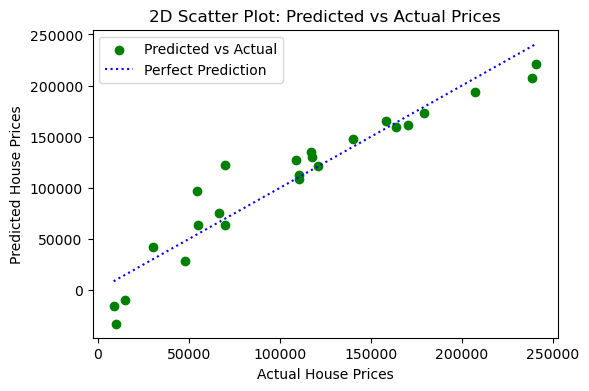

In [64]:
# Create scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_predict, color="green", label="Predicted vs Actual")  

# Add a perfect prediction reference line (y = x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="blue", linestyle=":", label="Perfect Prediction")

# Labels and title
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("2D Scatter Plot: Predicted vs Actual Prices")
plt.legend()
plt.show()

This 2D scatter plot compares the predicted house prices (y-axis) to the actual house prices (x-axis). The blue dotted line represents a perfect prediction of house_price, and the green dots represent the individual house price predictions made by the model. 
Most of the green data points are close to the blue line, which indicates that the model is making relatively accurate predictions, but some dots are above or below the lines, which means the model is overestimating and underestimating some of the house prices.

### Q6. Polynomial Regression

> 1. Generate polynomial features from Size, Num_Rooms, and Location_Score.  
o Use at least degree=2 (or higher if you wish). 

In [65]:
# Selecting features for polynomial expansion and Stores them in a new variable features
features = df_real_estate[['Size', 'Num_Rooms', 'Location_Score']]

# creating PolynomialFeatures with degree=2 and removes the extra column of ones. Store it in  poly variable.
poly = PolynomialFeatures(degree=2, include_bias=False)

# Generating polynomial feature combinations
poly_features = poly.fit_transform(features)

# generating column names for the transformed features.
feature_names = poly.get_feature_names_out(['Size', 'Num_Rooms', 'Location_Score'])

# Converting polynomial features into DataFrame for better read 
df_poly = pd.DataFrame(poly_features, columns=feature_names)

# Display the first few rows of the transformed data
print(df_poly.head())

         Size  Num_Rooms  Location_Score        Size^2  Size Num_Rooms  \
0  123.666251        1.0        0.453638  15293.341555      123.666251   
1  182.646689        1.0        8.811558  33359.812967      182.646689   
2   97.880197        3.0        8.934314   9580.532913      293.640590   
3   66.975090        2.0        3.337557   4485.662620      133.950179   
4  246.746365        6.0        3.385110  60883.768641     1480.478190   

   Size Location_Score  Num_Rooms^2  Num_Rooms Location_Score  \
0            56.099748          1.0                  0.453638   
1          1609.401926          1.0                  8.811558   
2           874.492368          9.0                 26.802941   
3           223.533196          4.0                  6.675115   
4           835.263650         36.0                 20.310662   

   Location_Score^2  
0          0.205788  
1         77.643558  
2         79.821959  
3         11.139288  
4         11.458971  


> 2. Train a polynomial regression model using these transformed features. 

In [66]:
# we already have poly data
poly = PolynomialFeatures(degree=2, include_bias=False)

# storing new set of features derived from the original
X_poly = poly.fit_transform(df_real_estate[['Size', 'Num_Rooms', 'Location_Score']])

# Split into features (X_poly) and target (House_Price)
X = X_poly
y = df_real_estate['House_Price']

# Split the data into training (80%) and testing (20%) sets
X_train_P, X_test_P, y_train_P, y_test_P = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the linear regression model to teach model the relationship between the input features and the target.
poly_reg_model = LinearRegression()

# Train the model with the polynomial features
poly_reg_model.fit(X_train_P, y_train_P) 




LinearRegression()

> 3. Evaluate the polynomial model using the same test set:  
o Print MSE, RMSE, and R². 


In [68]:
# Making predictions on the test set using the trained polynomial model
y_predict_P = poly_reg_model.predict(X_test_P)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_P, y_predict_P)
print(f"MSE: {mse:.2f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# Calculate R-squared 
r2 = r2_score(y_test_P, y_predict_P)
print(f"R²: {r2:.2f}")

MSE: 2345085.07
RMSE: 1531.37
R²: 1.00


> 4. Compare these metrics with the linear model from  Q4. Which model performs better? 

The Polynomial Model has a much lower MSE (2,345,085.07) compared to the Linear Model (456,393,114.66), which shows that the polynomial model's predictions are closer to the actual values because of the low value of MSE, the polynomial model also have low RMSE(1531.37) than linear model (21,363.36) means the polynomial model is doing better in terms of prediction accuracy based on this metric.

Regarding R-squared, The Polynomial Model has a perfect R² score of 1.00, meaning it explains 100% of the House Price variance, while the linear model shows 90% of the variance. 

                                                        
The polynomial model performs better than the linear model based on all three metrics; hence, the polynomial features capture the complexity in the data better than the linear features alone, as reflected in the improvement in these evaluation metrics.

### Q7. Tuning & Overfitting 

> 1. Discuss (in comments) how polynomial expansion can lead to overfitting.

Polynomial expansion can lead to overfitting when the degree of the polynomial is increased too much. As the polynomial degree rises, the model becomes more flexible and allows fitting noise and fluctuations specific to the training set. This makes a model perform well on the training data but struggle to generalize new, unseen data, leading to poor predictions.

> 2. Explain two strategies to reduce the risk of overfitting in polynomial regression. 

There are many strategies in polynomial regression to reduce the risk of overfitting.                

**1. Limit the PolynomialDegree:** Instead of using very high-degree polynomials, we can choose a degree that adequately captures the underlying trend of the data without fitting every minor fluctuation to avoid noise and random fluctuations.

**2. FeatureSelection:** Adding too many features can increase the risk of overfitting. Feature selection can reduce the dimension of the data and focus only on the most critical variables. We can create new features that have more information and remove uninformative ones.

> 3. (Bonus Question) Implement one of the strategies.

In [ ]:

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

# Compare coefficients
print("Linear Regression Coefficients:", my_model.coef_)
print("Lasso Regression Coefficients:", lasso_reg.coef_)

# Evaluate performance
print("\nLinear Regression MSE:", mean_squared_error(y_test, y_predict))
print("Lasso Regression MSE:", mean_squared_error(y_test, y_pred_lasso))


Linear Regression Coefficients: [  554.36219154  5211.14979813 16752.96141325]
Lasso Regression Coefficients: [ 2.41131360e+01 -7.91484333e+02  1.06600611e+02 -8.03859698e-02
  1.43524370e+00  9.98514452e+01  8.32261701e+02  4.84148731e+01
 -7.68131973e+01]

Linear Regression MSE: 456393114.6612069
Lasso Regression MSE: 2344986.1379700694


> 4. Implement a check with at least three different polynomial degrees (e.g., degree=2 vs.  degree=3 vs. 4) and report which gave better results on your test data.

In [ ]:
#Implemented with 4 degree range
check_Degree=[]

for poly_Degree in range(1,5):
    
    curr_Degree = PolynomialFeatures(degree=poly_Degree, include_bias=False)
    train_X_Poly = curr_Degree.fit_transform(X_train)
    test_X_Poly = curr_Degree.transform(X_test)
    degress_Poly_D = LinearRegression()
    degress_Poly_D.fit(train_X_Poly, y_train)
    d_predict = degress_Poly_D.predict(test_X_Poly)
    
    d_mse = mean_squared_error(y_test, d_predict)
    d_rmse = np.sqrt(d_mse)
    r2_Score_D = r2_score(y_test,d_predict)

    check_Degree.append({
        "Degree": poly_Degree,
        "MSE": d_mse,
        "RMSE":d_rmse,
        "R2 Score": r2_Score_D
    })
    
result = pd.DataFrame(check_Degree)
print(result)

   Degree           MSE          RMSE  R2 Score
0       1  2.345085e+06   1531.367059  0.999481
1       2  6.377954e+06   2525.461233  0.998588
2       3  1.774130e+08  13319.647489  0.960733
3       4  1.751495e+08  13234.406451  0.961234


The above data shows that the data is compared with four different degree, and it shows that the degree 2 and 3 are the optimal for testing data.

### Q8. Feature Importance & Interpretation 

1. Compare how easy/difficult it is to interpret the coefficients in linear vs. polynomial regression.

Linear regression is more straightforward to interpret because each coefficient represents a direct relationship between an independent variable and the target variable, meaning a one-unit change in a feature results in a fixed change in the output. In contrast, polynomial regression introduces higher-degree terms (e.g., $x^2, x^3 $)
 and interactions, making it difficult to isolate the individual effect of each feature.

> 2. Discuss why interpretability may decrease when using higher-degree polynomials.

Interpretability decreases when using higher-degree polynomials because the relationships between variables become more complex and less intuitive. Polynomial models often exhibit extreme sensitivity to small changes in input data, leading to fluctuating predictions that are hard to generalize. As the polynomial degree increases, the model may also capture noise rather than meaningful patterns, reducing interpretability and increasing the risk of overfitting.

> 3. Provide a short reflection on why interpretability might matter in real estate scenarios 
(e.g., for clients or realtors). 

Interpretability is crucial in real estate scenarios because clients and realtors need to understand how different factors—such as property size, number of rooms, and location—affect house prices. A simple, interpretable model allows realtors to confidently explain price estimates to clients, helping them make informed decisions. If a model is too complex, with high-degree polynomial relationships, it becomes difficult to justify why a particular property is valued higher or lower. Clear and transparent pricing models also build trust between buyers, sellers, and agents, making negotiations smoother.

> 4. Provide an example of how you might explain the model’s predictions to a non
technical stakeholder (e.g., a homeowner or realtor) who wants to know “why is my 
house valued at X?”

In [ ]:
X = df_real_estate[['Size', 'Num_Rooms', 'Location_Score']] 
y = df_real_estate['House_Price']                                   
X_train_p, X_test_p, y_train_p, y_test_P = train_test_split(X, y, test_size=0.2, random_state=42)
datas = ['Size', 'Num_Rooms', 'Location_Score'] 
data_test = pd.DataFrame(X_test_p, columns=datas)
data_test["Prediction"] = my_model.predict(X_test_p)
print(data_test.head())


          Size  Num_Rooms  Location_Score     Prediction
44  229.694021          6        5.834751  159148.014529
47   83.486417          2        0.459433  -32801.051302
4   246.746365          6        3.385110  127562.447355
55  173.218169          6        4.697609  108789.430653
26   87.726674          4        6.173960   75707.133669


I would explain to the homeowner or realtor that the price prediction is based on several key factors:

Size: Larger homes have higher values because they offer more space.

Number of Rooms: More rooms can increase the value as the property can accommodate more people or be used for various purposes.

Location Score: A higher location score means the property is in a more desirable area, which can significantly increase its value.

By comparing two houses—one larger and in a better location (Record 44) and one with approximately the same size and the same number of rooms in a less desirable location (Record 4), the model predicts a higher value for the first house due to these features. This makes the pricing predictions understandable based on the features of each home.

### Q9: Implement a hyperparameter tuning process (e.g., using a simple for-loop or cross validation with PolynomialFeatures) to search multiple polynomial degrees (2, 3, 4, …)

> 1. Print the test set R² (or RMSE) for each degree. Choose the best polynomial degree and explain your rationale.

In [ ]:

for degree_r2 in range(1,5):
    
    curr_Degree = PolynomialFeatures(degree=degree_r2, include_bias=False)
    train_X_Poly = curr_Degree.fit_transform(X_train_p)
    cr_validation = LinearRegression()
    score = cross_val_score(cr_validation, train_X_Poly,y_train,cv=5,scoring='r2')
    r2_mean = np.mean(score)
    print(f"R2 Score :{r2_mean}for Degree:{degree_r2}")


    
    


R2 Score :0.896760499823883for Degree:1
R2 Score :0.998665227102429for Degree:2
R2 Score :0.998297653105902for Degree:3
R2 Score :0.997511790546838for Degree:4


Cross-validation is a method used in machine learning to evaluate how well a model performs on an independent data set. It involves dividing the available data into multiple folds or subsets, using one of these folds as a validation set, and training the model on the remaining folds. This process is repeated numerous times, using a different fold as the validation set. Finally, the results from each validation step are averaged to produce a more robust estimate of the model's performance.
The R² score with degree 2 is 0.9987, which indicates a perfect fit. This suggests that the quadratic relationship between the features and target variable is much better at explaining the variation in house prices than the linear model(degree 1). 
Degrees 3 and 4 also show high R² scores (0.9983 and 0.9975, respectively), but in comparison to Degree 2, these values are small. 
Since Degree 2 provides the best balance between model performance (R² score) and simplicity. It captures the underlying relationships well without unnecessarily increasing the model's complexity. Thus, Degree 2 is the best choice in this case.

### Q10. Final Discussion 

> 1. Summarise which model (linear vs. polynomial) seems most appropriate for predicting house prices in this synthetic scenario. 

The polynomial regression model with Degree 2 seems most appropriate for predicting house prices. The linear regression model (Degree 1) had an R² score of 0.8968, indicating that it explains around 89.7% of the variance in the data. 
However, the polynomial regression model with Degree 2 achieved a significantly higher R² score of 0.9987, suggesting it better captures the complex, nonlinear relationships between the features (Size, Num_Rooms, and Location_Score) and house prices.

> 2. Speculate about any additional features (e.g., age of the building, local amenities) that might improve the model’s performance. 

Age of the Building:

Older homes may have lower values, while newer homes may have higher prices due to modern amenities and construction quality. Adding this feature could help capture the effect of age on house prices.

Local Amenities:

Accessibility to essential services like schools, parks, shopping centers, and public transportation can significantly influence property value. These features help account for location desirability and convenience.

> 3. Reflect on any limitations of the synthetic approach and how real-world data might differ. 


 **Simplified Assumptions**:

Synthetic data uses predefined, simplified relationships, but real-world data has complex, unpredictable relationships influenced by various factors.

 **Lack of Noise and Variability**:

Synthetic data introduces essential random noise. Real-world data includes inconsistent information, errors, outliers, and missing data.

 **Absence of Additional Features**:

Real-world data includes additional factors like the property's age, local amenities, neighborhood quality, and economic conditions.

 **External Influences**:

Synthetic data doesn't account for external influences like economic conditions and government policies. However, real-world data is affected by changing market dynamics and external factors that influence house prices.